Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading dataset from Drive...
Engineering features...
Encoding and flagging missing data...
Training XGBoost (Optimized Settings)...
[0]	validation_0-rmse:0.68000
[100]	validation_0-rmse:0.26576
[200]	validation_0-rmse:0.23792
[300]	validation_0-rmse:0.22828
[400]	validation_0-rmse:0.22205
[500]	validation_0-rmse:0.21749
[600]	validation_0-rmse:0.21411
[700]	validation_0-rmse:0.21158
[800]	validation_0-rmse:0.20936
[900]	validation_0-rmse:0.20776
[1000]	validation_0-rmse:0.20626
[1100]	validation_0-rmse:0.20508
[1200]	validation_0-rmse:0.20410
[1300]	validation_0-rmse:0.20321
[1400]	validation_0-rmse:0.20239
[1500]	validation_0-rmse:0.20166
[1600]	validation_0-rmse:0.20101
[1700]	validation_0-rmse:0.20042
[1800]	validation_0-rmse:0.19990
[1900]	validation_0-rmse:0.19941
[1999]	validation_0-rmse:0.19894

===== XGBOOST PERFORMANCE =====
RMSE: 0.1989
MAE : 0.144

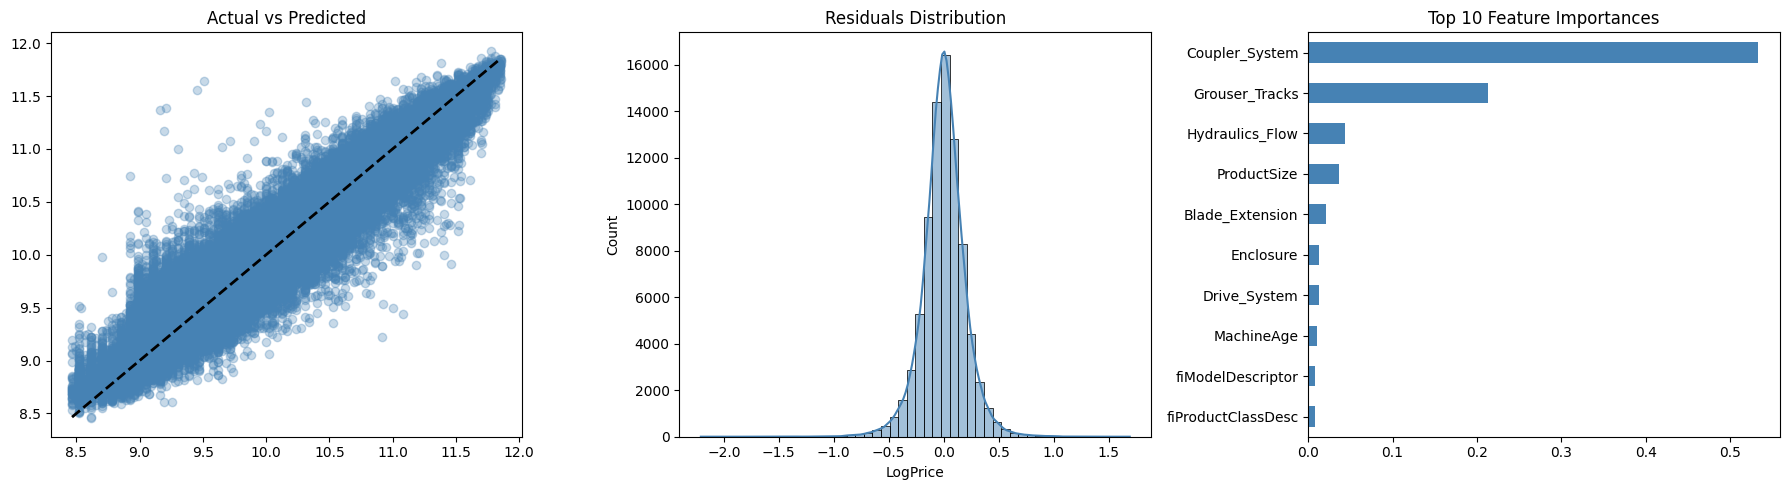

In [ ]:
"""
Group 2
Obil Nathaniel - 271048001
Muhammad Abdullah - 281134982
"""
# ==========================================
# EXPERIMENT 3: XGBOOST (GRADIENT BOOSTING)
# ==========================================
"""
OVERVIEW: This notebook uses XGBoost, a high-performance boosting algorithm
that builds trees SEQUENTIALLY. Each new tree focuses on correcting the
specific errors made by the previous trees, leading to higher precision.

STEPS:
1. TARGET SCALING: Log transform (np.log) to normalize price distribution
   and stabilize variance.
2. ADVANCED FEATURE ENGINEERING:
   - CYCLICAL ENCODING: Converted months into Sin/Cos waves so the model
     understands seasonal cycles (Dec and Jan are adjacent).
   - INFLATION TRACKING: Calculated 'YearsSinceMedian' to help the model
     observe long-term market price trends.
3. DATA SPLITTING: 80/20 split using random_state=42 for a fair
   comparison with Experiment 2.
4. IMPUTATION + MISSING FLAGS:
   - Calculated medians from the training set only.
   - Added binary '_is_missing' columns so the model can learn patterns
     from the absence of data.
5. OPTIMIZED MODELING: Used a slow learning rate (0.03) and deeper trees
   (max_depth=8) to capture complex depreciation rules.
6. EARLY STOPPING: Monitored validation error to stop training automatically
   once the model reached peak accuracy, preventing overfitting.

GOAL: To surpass the Random Forest baseline by using sequential learning
      and richer feature signals.
"""

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ----------------------------
# 1. Mount & Load
# ----------------------------
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/ML/TrainAndValid.csv'

print("Loading dataset from Drive...")
df = pd.read_csv(file_path, low_memory=False)

# ----------------------------
# 2. Target Transformation
# ----------------------------
df['LogPrice'] = np.log(df['SalePrice'])

# ----------------------------
# 3. Advanced Feature Engineering
# ----------------------------
print("Engineering features...")
df['saledate'] = pd.to_datetime(df['saledate'])
df['SaleYear']  = df['saledate'].dt.year
df['SaleMonth'] = df['saledate'].dt.month
df['SaleDay']   = df['saledate'].dt.day
df['DayOfWeek'] = df['saledate'].dt.dayofweek
df.drop('saledate', axis=1, inplace=True)

df['YearMade']   = df['YearMade'].replace(1000, np.nan)
df['MachineAge'] = df['SaleYear'] - df['YearMade']

# Cyclical month encoding
df['MonthSin'] = np.sin(2 * np.pi * df['SaleMonth'] / 12)
df['MonthCos'] = np.cos(2 * np.pi * df['SaleMonth'] / 12)
df['YearsSinceMedian'] = df['SaleYear'] - df['SaleYear'].median()

# ----------------------------
# 4. Leak-Proof Preprocessing
# ----------------------------
print("Encoding and flagging missing data...")

# Categorical Encoding
for label, content in df.items():
    if pd.api.types.is_string_dtype(content) or pd.api.types.is_object_dtype(content):
        df[label] = content.astype("category").cat.as_ordered()
        df[label] = df[label].cat.codes + 1

# Split FIRST to prevent median leak
X = df.drop(['SalePrice', 'LogPrice'], axis=1)
y = df['LogPrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Impute using Training Medians + Add Missing Flags
for label, content in X_train.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            # Add missing flag
            X_train[label + "_is_missing"] = pd.isnull(content).astype(int)
            X_test[label + "_is_missing"] = pd.isnull(X_test[label]).astype(int)

            # Fill with training median
            mid = content.median()
            X_train[label] = X_train[label].fillna(mid)
            X_test[label] = X_test[label].fillna(mid)

# ----------------------------
# 5. High-Performance Modeling
# ----------------------------
print("Training XGBoost (Optimized Settings)...")

model_xgb = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.03,    # Slower learning for better accuracy
    max_depth=8,           # Deeper trees to capture complex logic
    min_child_weight=2,    # Slight regularization
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    objective='reg:squarederror',
    tree_method='hist',    # Optimized for large data
    early_stopping_rounds=100
)

model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

# ----------------------------
# 6. Evaluation
# ----------------------------
y_pred = model_xgb.predict(X_test)

print("\n===== XGBOOST PERFORMANCE =====")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R2  : {r2_score(y_test, y_pred):.4f}")

# ----------------------------
# 7. Visualizations
# ----------------------------
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title("Actual vs Predicted")

plt.subplot(1, 3, 2)
sns.histplot(y_test - y_pred, bins=50, kde=True, color='steelblue')
plt.title("Residuals Distribution")

plt.subplot(1, 3, 3)
feat_importances = pd.Series(model_xgb.feature_importances_, index=X_train.columns)
feat_importances.nlargest(10).sort_values().plot(kind='barh', color='steelblue')
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()